#Customer Churn Prediction System using Machine Learning

#Business Problem Statement: Customer acquisition costs are significantly higher than customer retention costs. losing customers directly impacts company revenue, market share, and long-term growth.

#Step 1. Import Libraries

In [ ]:
#Pandas - for data manipulation
import pandas as pd

#Numpy - for numerical operations
import numpy as np

#Matplotlib - for data visualization
import matplotlib.pyplot as plt

#Seaborn - for data visualization
import seaborn as sns

#Sklearn - for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)



#warnings library for hiding unnecessary
import warnings
warnings.filterwarnings('ignore')

#Step 2. Load Dataset

In [ ]:
# Read CSV File
df=pd.read_csv('/content/customer_churn_prediction_30000_rows.csv')

# Display first 10 rows
df.head(10)  # to see top 10 rows, but by default head shows top 5 values

,CustomerID,Gender,SeniorCitizen,Partner,TenureMonths,InternetService,TechSupport,PaperlessBilling,PaymentMethod,ContractType,MonthlyCharges,TotalCharges,Churn
0,1,Male,0,1,52,DSL,Yes,No,Mailed check,Two year,115.07,6261.27,Yes
1,2,Male,0,1,61,DSL,Yes,Yes,Mailed check,Month-to-month,79.69,4808.43,No
2,3,Female,1,0,24,Fiber optic,No,Yes,Mailed check,Month-to-month,85.09,1860.98,Yes
3,4,Female,1,0,30,Fiber optic,Yes,Yes,Credit card,Month-to-month,41.23,1158.19,Yes
4,5,Female,0,0,21,Fiber optic,Yes,No,Electronic check,Two year,81.75,1755.09,No
5,6,Male,1,1,49,No,Yes,No,Electronic check,Month-to-month,72.48,3480.39,No
6,7,Female,0,0,60,No,No,Yes,Bank transfer,One year,56.64,3368.54,No
7,8,Male,1,0,47,No,Yes,Yes,Credit card,Two year,81.84,3756.06,No
8,9,Female,0,1,64,DSL,No,No,Bank transfer,Month-to-month,66.68,4574.73,Yes
9,10,Female,1,1,7,No,No,Yes,Bank transfer,One year,37.05,236.79,Yes


#Step 3. Understand Dataset

In [ ]:
print(df.shape)  #shape is a type of attribute and shows the amount of rows and columns

print(df.info()) #info is a function used column names, missing values, and data types

print(df.columns) #columns is an attribute used to show all column names

print(df.describe()) #describe is a function used to show statistical summary including mean, median and standard deviation

(30000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        30000 non-null  int64  
 1   Gender            30000 non-null  object 
 2   SeniorCitizen     30000 non-null  int64  
 3   Partner           30000 non-null  int64  
 4   TenureMonths      30000 non-null  int64  
 5   InternetService   30000 non-null  object 
 6   TechSupport       30000 non-null  object 
 7   PaperlessBilling  30000 non-null  object 
 8   PaymentMethod     30000 non-null  object 
 9   ContractType      30000 non-null  object 
 10  MonthlyCharges    30000 non-null  float64
 11  TotalCharges      30000 non-null  float64
 12  Churn             30000 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 3.0+ MB
None
Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'TenureMonths',
       'InternetService', 'TechS

#Step 4. Check Missing Values

In [ ]:
print(df.isnull().sum()) #isnull is a function used to check missing values

print(df.isnull().sum().sum()) #used to see overall data set has null values

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
TenureMonths        0
InternetService     0
TechSupport         0
PaperlessBilling    0
PaymentMethod       0
ContractType        0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0


#Step 5. Handle Missing Values - If any

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns # Selecting categorical columns

numerical_cols = df.select_dtypes(exclude=['object']).columns # Selecting numerical columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True) # Filling missing values with mode

for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True) # Filling missing values with mean

#Step 6. Check duplicate Records

In [ ]:
# duplicated () checks duplicate rows
print (df.duplicated().sum())

#Remove duplicates
df.drop_duplicates(inplace=True)

0


#Step 7. Exploratory Data Analysis (EDA)
purpose:
- Understand Problem
- Find patterns
- Detect outliers
- Detect relationships
- Generate business insights to help company make more profit

#Churn Distribution Graph

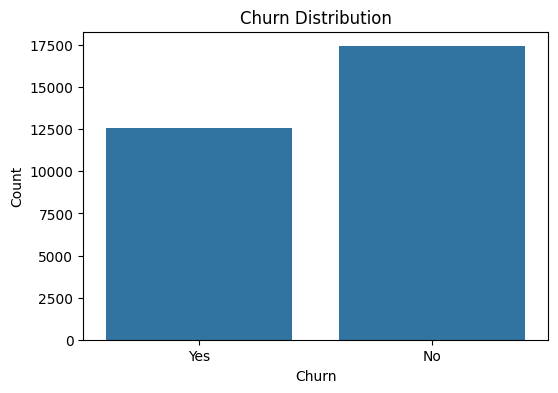

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

#Contract Type Analysis

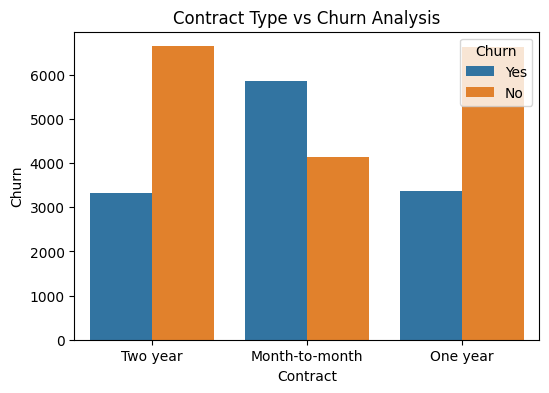

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='ContractType', hue='Churn', data=df) #hue lets us apply charts format
plt.title('Contract Type vs Churn Analysis')
plt.xlabel('Contract')
plt.ylabel('Churn')
plt.show()

#Montly Charges distribution

In [ ]:
df

,CustomerID,Gender,SeniorCitizen,Partner,TenureMonths,InternetService,TechSupport,PaperlessBilling,PaymentMethod,ContractType,MonthlyCharges,TotalCharges,Churn
0,1,Male,0,1,52,DSL,Yes,No,Mailed check,Two year,115.07,6261.27,Yes
1,2,Male,0,1,61,DSL,Yes,Yes,Mailed check,Month-to-month,79.69,4808.43,No
2,3,Female,1,0,24,Fiber optic,No,Yes,Mailed check,Month-to-month,85.09,1860.98,Yes
3,4,Female,1,0,30,Fiber optic,Yes,Yes,Credit card,Month-to-month,41.23,1158.19,Yes
4,5,Female,0,0,21,Fiber optic,Yes,No,Electronic check,Two year,81.75,1755.09,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,Female,0,0,23,Fiber optic,Yes,No,Mailed check,Month-to-month,110.57,2408.98,Yes
29996,29997,Male,1,1,44,DSL,Yes,No,Credit card,One year,106.32,5108.31,No
29997,29998,Female,0,0,19,Fiber optic,Yes,Yes,Mailed check,Two year,77.00,1571.01,No
29998,29999,Female,1,1,52,Fiber optic,Yes,Yes,Bank transfer,Month-to-month,69.76,3368.22,No


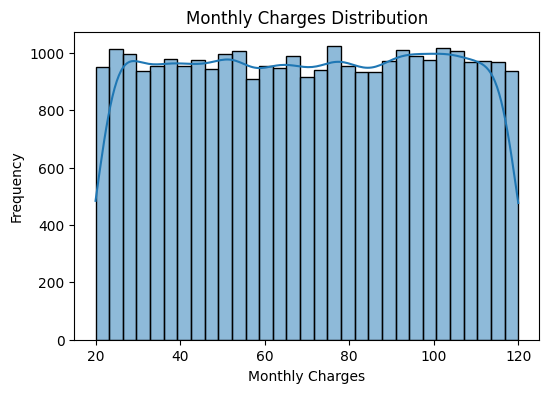

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df['MonthlyCharges'], kde=True)  #the smooth blue line is called Kernal Density Estimation (KDE), helps visualize the probablity of desity of the data
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()
#

We use this graph to understand the distribution of a numerical feature.


To detect skewness , outliers, and the data spread, peaks in the data.



#Correlation Heatmap


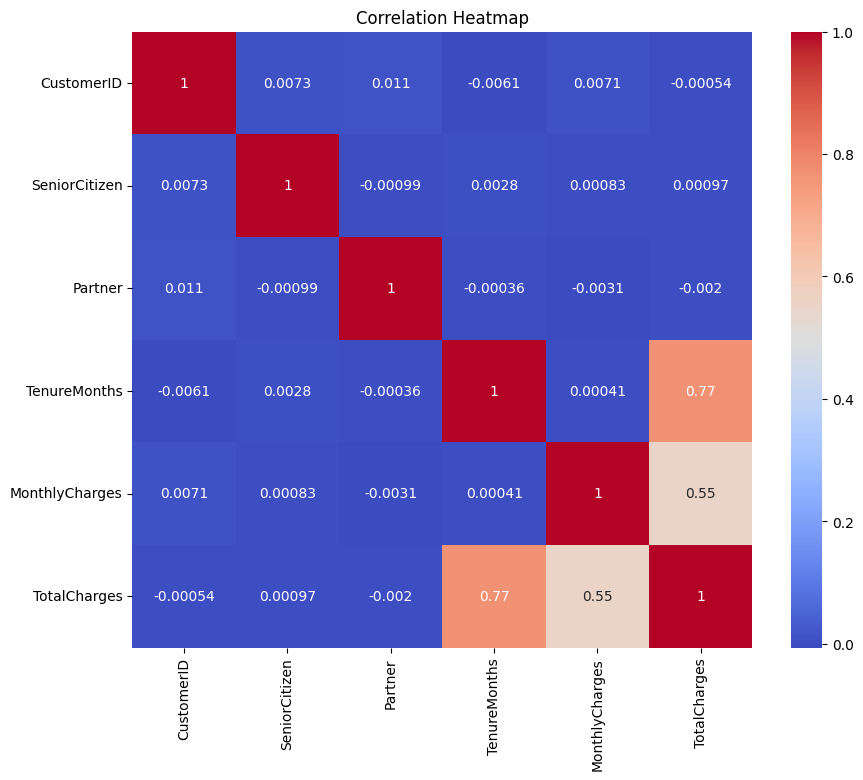

In [ ]:
correlation = df.corr(numeric_only=True) # corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
#

#Step 8. Encoding Categorical Data

In [ ]:
# Create encoder object
le = LabelEncoder()

# Convert text into numbers
for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

# Step 9. Define Features and Target

In [ ]:
# Independent Variables
X = df.drop(["CustomerID", "Churn"], axis=1)

# Dependent Variable
y = df["Churn"]


# Step 10. Feature Scaling

In [ ]:
# Create scaler object
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Step 11. Train-Test Split

In [ ]:
# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (24000, 11)
X_test shape: (6000, 11)


# Step 12. Create Multiple Algorithms

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Step 13. Train All Models Automatically

In [ ]:
results = []

for name, model in models.items():

  print('='*60)
  print("Algorithm:", name)

  # Train model
  model.fit(X_train, y_train)

  # Prediction
  y_pred = model.predict(X_test)

  # Accuracy
  acc = accuracy_score(y_test, y_pred)
  print("Accuracy:", round(acc*100,2), "%")

  # Classification Report
  print("Classification Report:")
  print(classification_report(y_test, y_pred))

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix:")
  print(cm)

  results.append([name, acc])

Algorithm: Logistic Regression
Accuracy: 63.47 %
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      3470
           1       0.60      0.39      0.47      2530

    accuracy                           0.63      6000
   macro avg       0.62      0.60      0.60      6000
weighted avg       0.63      0.63      0.62      6000

Confusion Matrix:
[[2823  647]
 [1545  985]]
Algorithm: Support Vector Machine
Accuracy: 64.77 %
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.79      0.72      3470
           1       0.61      0.46      0.52      2530

    accuracy                           0.65      6000
   macro avg       0.64      0.62      0.62      6000
weighted avg       0.64      0.65      0.64      6000

Confusion Matrix:
[[2725  745]
 [1369 1161]]
Algorithm: K-Nearest Neighbors
Accuracy: 58.97 %
Classification Report:
              precision    recall  f1

# Step 14. Compare All Models

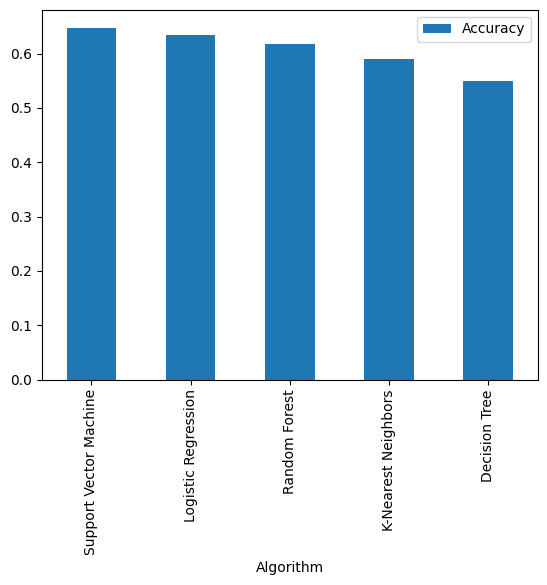

                        Accuracy
Algorithm                       
Support Vector Machine  0.647667
Logistic Regression     0.634667
Random Forest           0.617000
K-Nearest Neighbors     0.589667
Decision Tree           0.550167


In [ ]:
result_df = pd.DataFrame(results, columns=['Algorithm', 'Accuracy'])
result_df = result_df.sort_values(by='Accuracy', ascending=False)
result_df = result_df.set_index('Algorithm')
result_df.plot(kind='bar')
plt.show()
print(result_df)

# Step 15. Find Best Model Automatically

In [ ]:
best_model = result_df.iloc[0]
print('Best Algorithm:')

print("Best Model:", best_model)

Best Algorithm:
Best Model: Accuracy    0.647667
Name: Support Vector Machine, dtype: float64


# Step 16. Visualize Accuracy

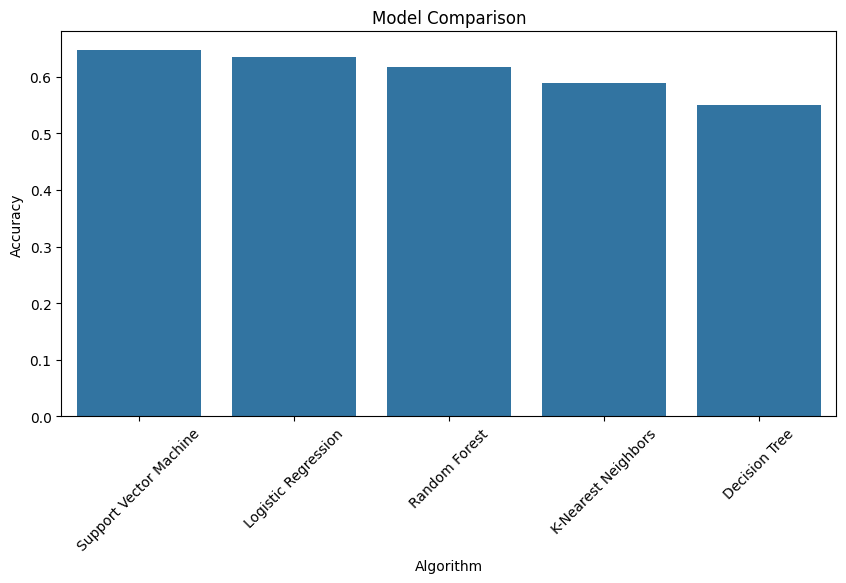

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(x="Algorithm", y="Accuracy", data=result_df)

plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

# Step 17. ROC-AUC Score

In [ ]:
for name, model in models.items():
  # Fit the model again to ensure it's trained before calling predict_proba
  model.fit(X_train, y_train)

  y_prob = model.predict_proba(X_test)[:, 1]

  auc = roc_auc_score(y_test, y_prob)

  print(name, "ROC-AUC =", auc)

Logistic Regression ROC-AUC = 0.6473900513720086
Support Vector Machine ROC-AUC = 0.6561009670695175
K-Nearest Neighbors ROC-AUC = 0.5951245002335092
Decision Tree ROC-AUC = 0.5360708956498957
Random Forest ROC-AUC = 0.6325513435317971


# Step 18. Save Best Model

In [ ]:
import joblib

# Save Model
joblib.dump(model, "churn_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Step 19. Load Saved Model

In [ ]:
import joblib

model = joblib.load("churn_prediction_model.pkl")

# Step 20. Predict New Customer

In [ ]:
new_customer = [[
    1,      # Gender
    0,      # Senior Citizen
    1,      # Partner
    5,      # Tenure
    1,      # Internet Service
    0,      # Tech Support
    1,      # Paperless Billing
    2,      # Payment Method
    0,      # Contract Type
    95,     # Monthly Charges
    450     # Total Charges
]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

Customer Will Churn


# Step 21. Advanced Algorithm (XGBoost)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

acc = accuracy_score(y_test, pred)

print("XGBoost Accuracy:", acc)

XGBoost Accuracy: 0.6293333333333333


# Step 22. Feature Importance

In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
9     MonthlyCharges    0.254665
10      TotalCharges    0.247613
3       TenureMonths    0.191592
8       ContractType    0.077125
7      PaymentMethod    0.065518
4    InternetService    0.033341
2            Partner    0.029240
0             Gender    0.028848
1      SeniorCitizen    0.028604
6   PaperlessBilling    0.028002
5        TechSupport    0.015451


In [ ]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

Churn
0    17423
1    12577
Name: count, dtype: int64
Churn
0    58.076667
1    41.923333
Name: proportion, dtype: float64
